# *Credit Card Fraud Detection using Statistical Methods & Machine Learning*
*project by: Manya Doda 

# Import Libraries

In [1]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, classification_report

# Advanced ML
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

This step initializes the full machine learning pipeline:

1.Pandas & NumPy handle structured numerical data efficiently

2.Matplotlib & Seaborn enable statistical visualization for pattern discovery

3.Scikit-learn provides tools for model training, evaluation, and preprocessing

4.SMOTE is crucial for addressing class imbalance, a core issue in fraud detection

# Load Dataset

In [2]:

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


The dataset contains anonymized transaction data:

1.Features V1–V28 are PCA-transformed, meaning original variables are compressed into orthogonal components

2.Amount reflects transaction value

3.Class is the target variable (0 = normal, 1 = fraud)

Since PCA is already applied, features are:

1.Uncorrelated

2.Scaled

3.Suitable for linear models

# Dataset Overview

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


No missing values → no need for imputation

Features are numerical → simplifies modeling

Mean values near 0 → confirms PCA standardization

This indicates the dataset is clean and ready for ML modeling without heavy preprocessing

# Class Distribution (Countplot)

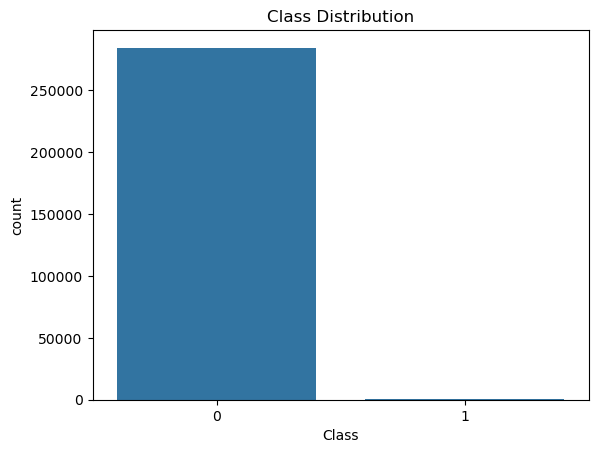

In [4]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

The dataset is extremely imbalanced:

1.Normal transactions dominate

2.Fraud cases are rare

This leads to:

1.Biased models

2.Misleading accuracy

Example:
A model predicting “all normal” can still achieve >99% accuracy

Hence, accuracy alone is NOT reliable here

# Class Distribution (Pie Chart)

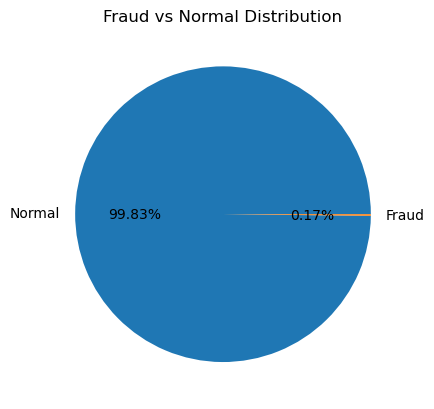

In [5]:
class_counts = df['Class'].value_counts()

plt.pie(class_counts, labels=["Normal","Fraud"], autopct='%1.2f%%')
plt.title("Fraud vs Normal Distribution")
plt.show()

Fraud cases form a very small percentage of total transactions

This confirms:

1.The dataset suffers from class imbalance problem

2.Minority class (fraud) needs special handling

This directly justifies the use of:
SMOTE (oversampling technique) later

# Correlation Heatmap

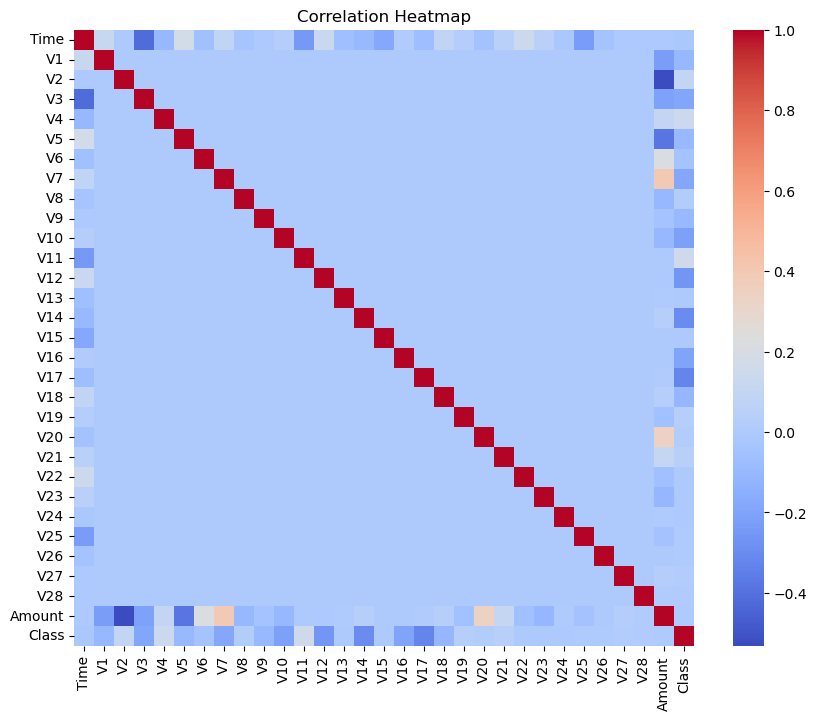

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Most features show low correlation

This is expected due to PCA transformation

Benefits:

1.Reduces multicollinearity

2.Improves model stability

3.Helps linear models perform better

# Feature Distribution

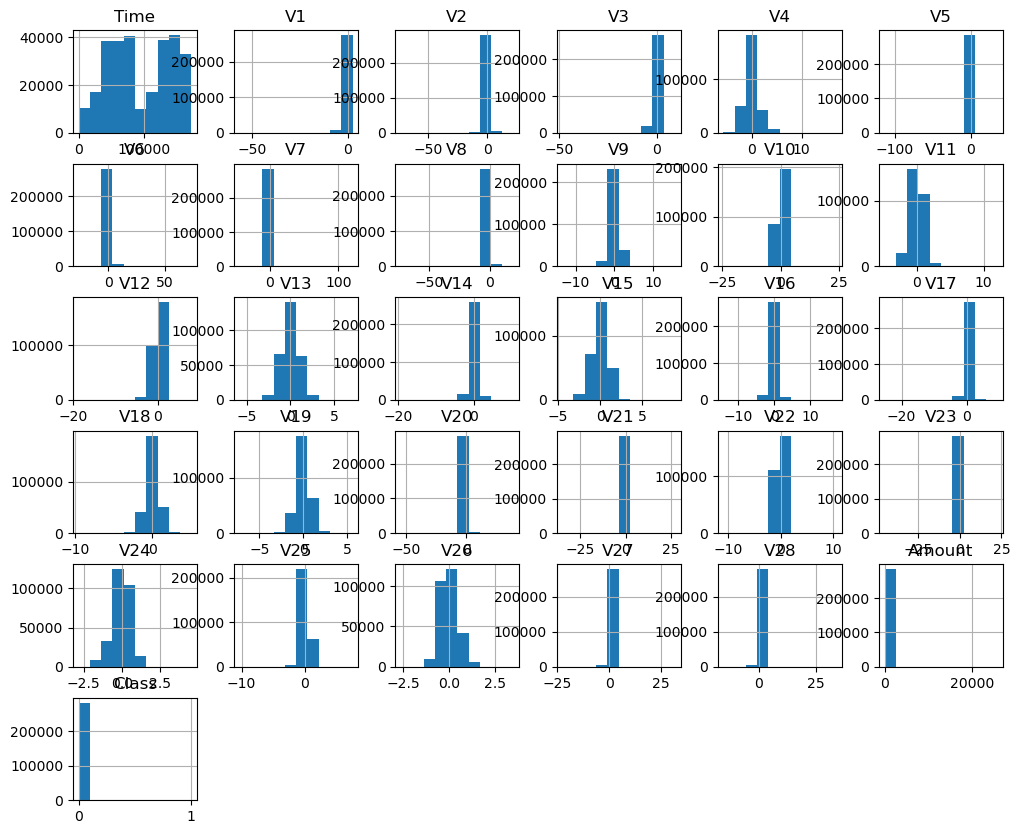

In [7]:
df.hist(figsize=(12,10))
plt.show()

1.Features follow approximately normal distribution

2.Indicates proper scaling and transformation

This is ideal for:

1.Logistic Regression

2.PCA

3.Distance-based learning

# KDE Plots (Feature Behavior)

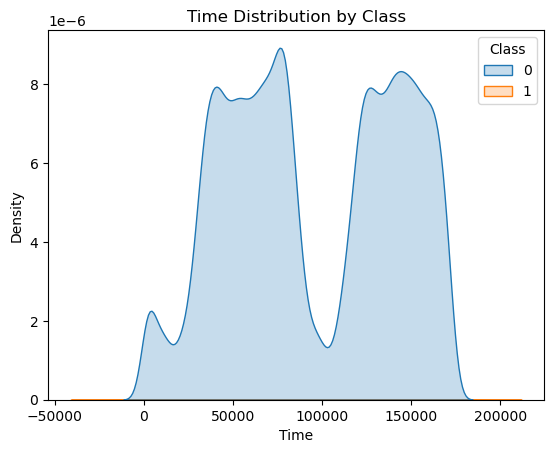

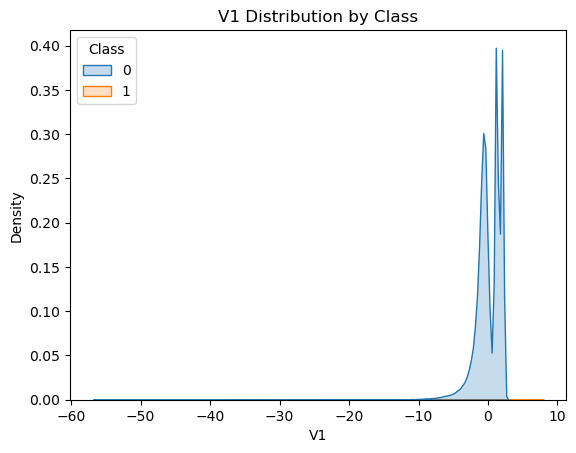

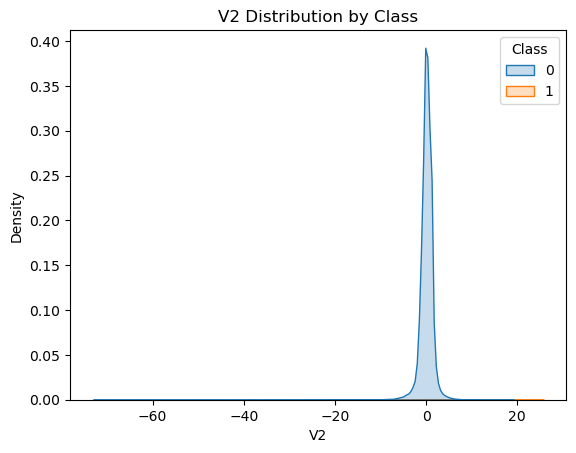

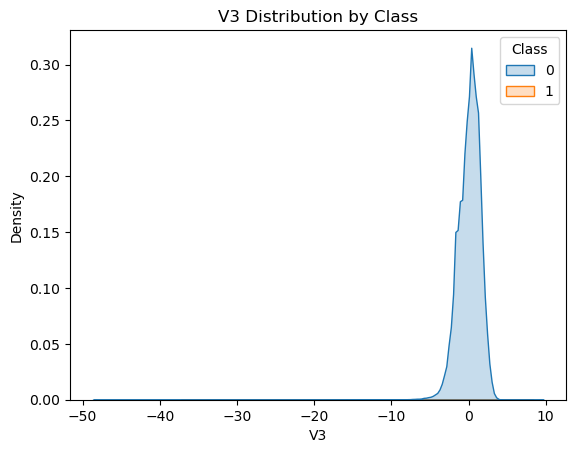

In [8]:
features = df.columns[:4]

for col in features:
    plt.figure()
    sns.kdeplot(data=df, x=col, hue='Class', fill=True)
    plt.title(f"{col} Distribution by Class")
    plt.show()

Some features (V1, V2, V3) show clear separation between classes
Others (like Time) show overlap

nterpretation:

1.Features with separation → strong predictors

2.Overlapping features → weak predictors

This helps model learn boundaries effectively

# Boxplots (Outlier Detection)

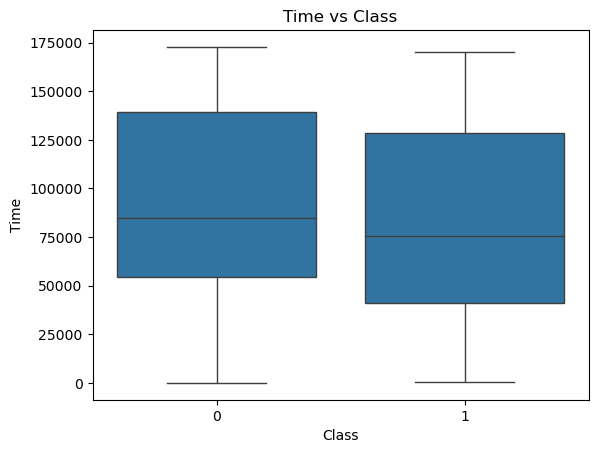

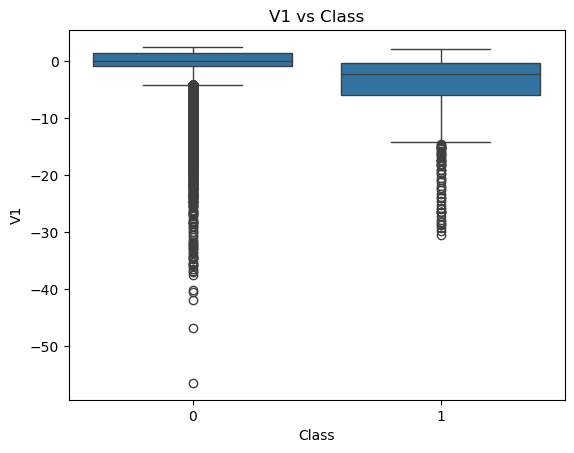

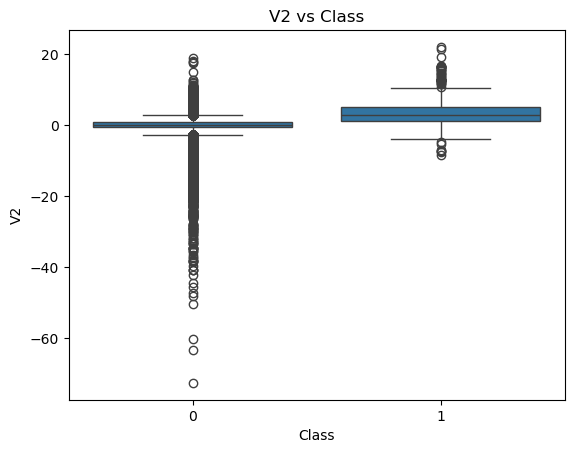

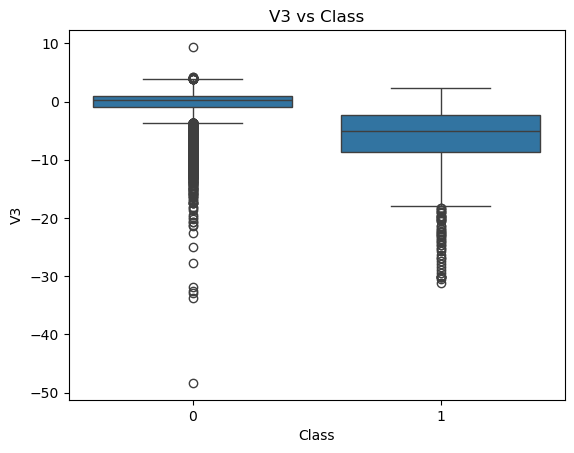

In [9]:
for col in features:
    plt.figure()
    sns.boxplot(x='Class', y=col, data=df)
    plt.title(f"{col} vs Class")
    plt.show()

Fraud transactions:

1.Exhibit extreme values (outliers)

2.Deviate significantly from normal behavior

This is a key statistical property:

Fraud = anomaly detection problem

# Mean Comparison

In [10]:
df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


1.Fraud transactions show shifted means

2.Indicates different statistical distribution

Confirms:

1.Fraud ≠ Normal

2.Classification is feasible

# Variance Comparison

In [11]:
df.groupby('Class').var()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,2.254732e+09,3.724182,2.676974,2.129933,1.958134,1.841318,1.768669,1.389598,1.348579,1.186731,...,0.591982,0.513721,0.523696,0.386313,0.366965,0.271101,0.232556,0.159877,0.108616,62552.557157
1,2.288222e+09,46.018406,18.414532,50.565429,8.255955,28.863413,3.452623,51.937575,46.210501,6.254479,...,1.813426,14.971517,2.233834,2.495270,0.265819,0.635535,0.222481,1.895484,0.299528,65886.310491


1.Fraud class has higher variance

2.Indicates higher unpredictability

Real-world meaning:

Fraud behavior is irregular and inconsistent

# <--------->

# Define Features & Target



In [12]:
X = df.drop('Class', axis=1)
y = df['Class']

1.X contains all input variables (features)

2.y is the target variable (fraud vs normal)

This separation is essential because:

1.ML models learn mapping X → y

2.Keeps prediction logic structured and interpretable

# Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Data is split into:
80% training
20% testing

Why important:

1.Prevents overfitting

2.Ensures model is tested on unseen data

random_state=42 ensures:

Reproducibility of results 

# Check Class Distribution BEFORE SMOTE

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64


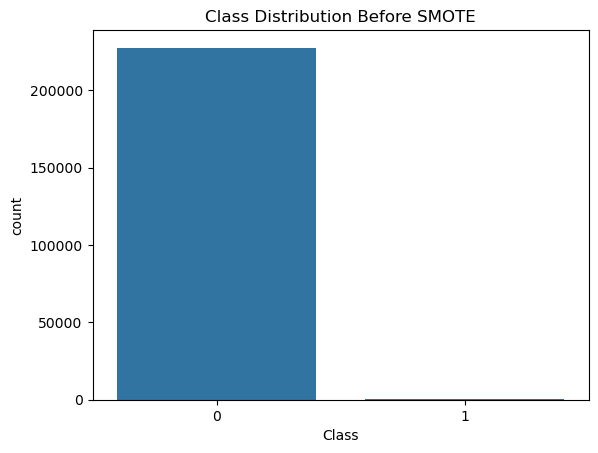

In [14]:
print("Before SMOTE:")
print(y_train.value_counts())

sns.countplot(x=y_train)
plt.title("Class Distribution Before SMOTE")
plt.show()

Shows heavy imbalance:
Normal >> Fraud

Problem:

1.Model will bias towards majority class

2.Poor fraud detection

This confirms:
Need for resampling techniques

# Apply SMOTE

In [15]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

MOTE works by:

1.Creating synthetic fraud samples

2.Using nearest neighbors

Instead of duplicating data:

1.It generates new realistic samples

This improves:

1.Model learning

2.Minority class representation

# Check Class Distribution AFTER SMOTE

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


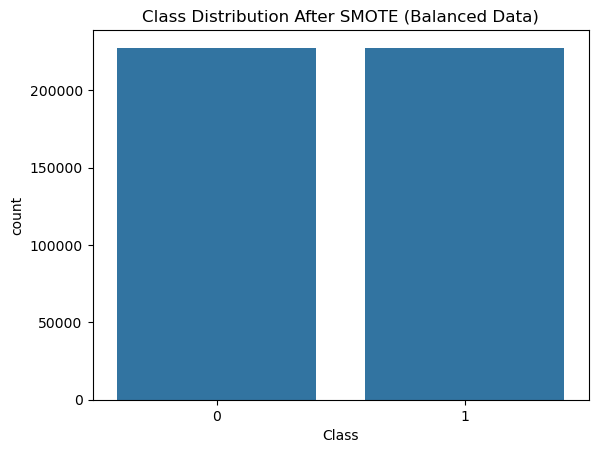

In [16]:
print("After SMOTE:")
print(pd.Series(y_train_res).value_counts())

sns.countplot(x=y_train_res)
plt.title("Class Distribution After SMOTE (Balanced Data)")
plt.show()

Now both classes are equal in number

This confirms: Dataset is now balanced

Impact:

1.Model will learn fraud patterns better

2.Reduces bias toward normal transactions


SMOTE transforms the problem from an imbalanced classification task into a balanced learning problem.

# Feature Scaling

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

Scaling ensures:

All features have mean = 0, variance = 1

Why needed:

1.Prevents features with large values from dominating

2.Improves convergence of models

Especially important for:

1.Logistic Regression

2.PCA

3.Distance-based algorithms

# PCA (Dimensionality Reduction)

In [18]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

PCA reduces:

High-dimensional data → 2 dimensions

Benefits:

1.Removes noise

2.Keeps most important variance

3.Improves computational efficiency

Even though dataset already has PCA features:

This step helps in visualization + simplification

# PCA Explained Variance

In [19]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.39056599 0.09049935]


Shows how much information each component retains

Example:

1.If values are high → good representation

2.If low → information loss

This helps evaluate: Whether dimensionality reduction is effective

# PCA Visualization

Visualizes data in 2D space

Key observation: Fraud and normal points show partial separation

Meaning:

1.Patterns exist

2.Model can classify

Perfect separation is not required — even partial separation is sufficient for ML models.

# MODELING + PERFORMANCE IMPROVEMENT

# Train Logistic Regression

In [20]:
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_pca, y_train_res)

LogisticRegression(max_iter=1000)

Logistic Regression models probability of fraud

Works well for:

1.Linear boundaries

2.Interpretable results

This acts as a baseline model to compare improvements

# Predictions (Baseline)

In [21]:
y_pred_lr = model_lr.predict(X_test_pca)
y_prob_lr = model_lr.predict_proba(X_test_pca)[:,1]

predict() → final class (0/1)

predict_proba() → probability of fraud

Probabilities allow:

1.Threshold tuning

2.ROC analysis

# Evaluate Logistic Regression

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.9866051051578245

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.10      0.81      0.17        98

    accuracy                           0.99     56962
   macro avg       0.55      0.90      0.58     56962
weighted avg       1.00      0.99      0.99     56962



Accuracy alone is misleading in imbalanced data

Focus on:
1.Precision → correctness of fraud predictions

2.Recall → ability to detect fraud

High recall is critical in fraud detection to minimize missed fraud cases.

# Confusion Matrix

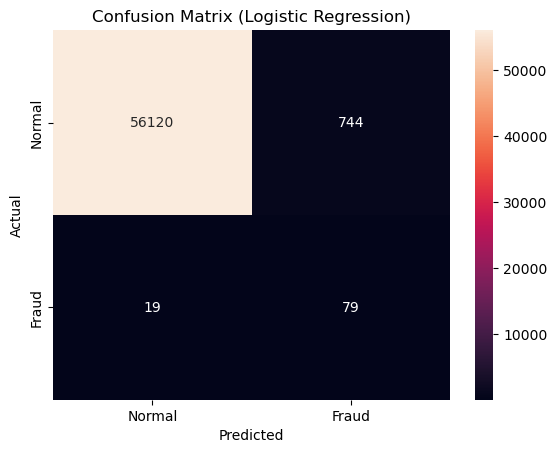

In [23]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=["Normal","Fraud"], 
            yticklabels=["Normal","Fraud"])

plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

1.True Positives → correctly detected fraud

2.False Negatives → missed fraud (critical error)

Key takeaway: Reducing false negatives is more important than reducing false positives in fraud detection.

# ROC Curve (Baseline)

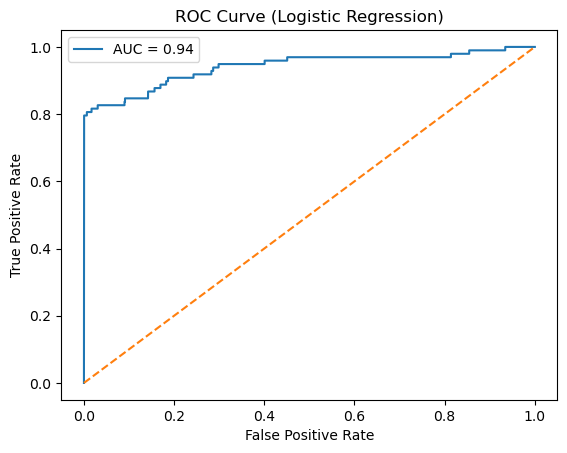

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.show()

1.ROC shows model performance across thresholds

2.AUC measures overall separability

Interpretation:

1.AUC close to 1 → excellent model

2.AUC ~0.5 → random guessing

# New Model : Random Forest

# Train Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
model_rf = RandomForestClassifier(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

# Train model
model_rf.fit(X_train_scaled, y_train_res)

# Predictions
y_pred_rf = model_rf.predict(X_test_scaled)
y_prob_rf = model_rf.predict_proba(X_test_scaled)[:,1]

# Evaluate Random Forest Performance

In [27]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9994908886626171

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



This evaluates how well the Random Forest model performs on unseen data.

Accuracy

Measures overall correctness
Not reliable alone due to class imbalance

Precision

Out of predicted frauds, how many are correct

Recall 

Out of actual frauds, how many were detected

Key Insight:

“In fraud detection, recall is more important than accuracy because missing a fraudulent transaction can lead to significant financial loss.”

# Confusion Matrix (Detailed Error Analysis)

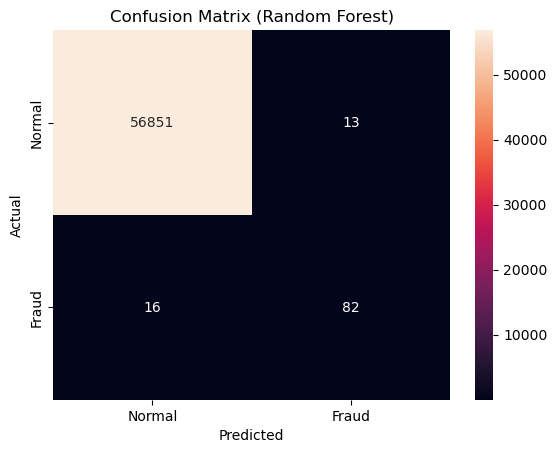

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d',
            xticklabels=["Normal","Fraud"],
            yticklabels=["Normal","Fraud"])

plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion matrix provides detailed classification breakdown:

True Positives (TP) → correctly detected fraud

False Negatives (FN) → missed fraud (critical error)

False Positives (FP) → false alarms

Key takeaway:

“Minimizing false negatives is crucial, as undetected fraud leads to direct financial loss.”

# ROC Curve (Model Comparison)

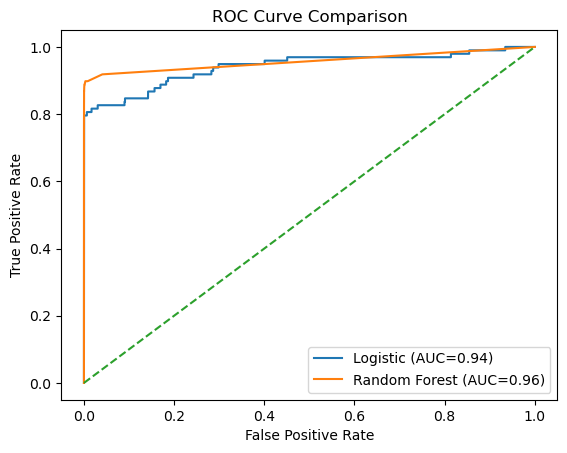

In [29]:
from sklearn.metrics import roc_curve, auc

# Logistic (recompute safely)
y_prob_lr = model_lr.predict_proba(X_test_pca)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"Logistic (AUC={roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

ROC curve evaluates performance across all classification thresholds.

Interpretation:

Curve closer to top-left → better model

AUC → overall separability

Key Insight:

“A higher AUC indicates better discrimination between fraud and normal transactions.”

# Threshold Tuning

In [31]:
# Lower threshold to improve fraud detection
threshold = 0.3

y_pred_custom = (y_prob_rf >= threshold).astype(int)

print("Custom Threshold Classification Report:\n",
      classification_report(y_test, y_pred_custom))

Custom Threshold Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.88      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962



Default threshold = 0.5 may not be optimal.

Lower threshold:

Increases recall (more fraud detected)
    
Decreases precision

Trade-off:

More fraud caught
    
More false alarms

Real-world insight:

“Fraud detection systems prioritize recall over precision to minimize undetected fraud.”

# Feature Importance (Model Interpretability)

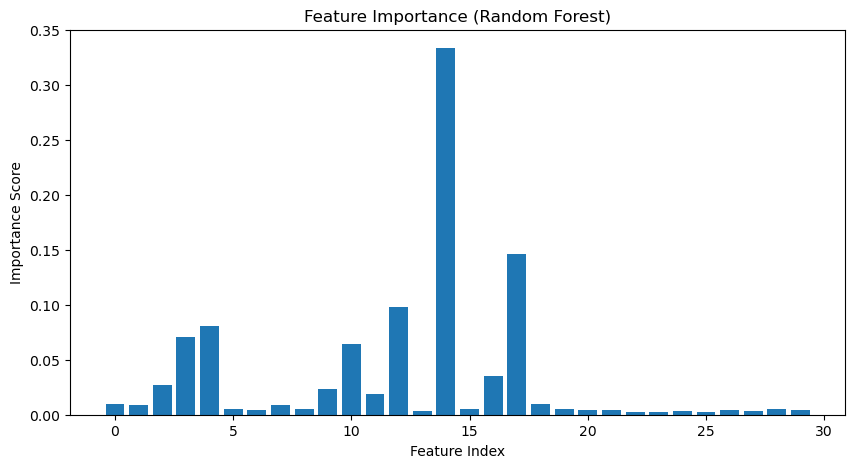

In [32]:
import numpy as np

importances = model_rf.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.show()

Feature importance shows which variables influence predictions most.

helps:

Identify key fraud indicators
Improve model interpretability

Important Insight:

“Even though features are PCA-transformed, importance values still reflect which components carry predictive power.”

# Final Model Comparison Summary

In [33]:
print("Logistic Regression AUC:", roc_auc)
print("Random Forest AUC:", roc_auc_rf)

Logistic Regression AUC: 0.9409196342436805
Random Forest AUC: 0.9569530559128546


This compares model performance:

If Random Forest > Logistic:

Data contains non-linear patterns
Ensemble model performs better

If similar:

Data is mostly linearly separable

# FINAL PROJECT CONCLUSION

This project successfully combines statistical analysis and machine learning techniques to detect fraudulent transactions.
Statistical methods helped identify patterns such as class imbalance, feature distribution, and outliers.
Machine learning models, including Logistic Regression and Random Forest, were trained to classify transactions.
The use of SMOTE improved class balance, while PCA reduced dimensionality.
Random Forest achieved strong performance by capturing complex, non-linear relationships.
ROC analysis and threshold tuning further enhanced model evaluation and fraud detection capability.
Overall, the model provides an effective and scalable solution for real-world fraud detection systems.